In [1]:
import os
import subprocess
from pathlib import Path
import tempfile

try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)

import gdsfactory as gf
from gdsfactory import Component
from gdsfactory.components import text_freetype, rectangle
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring
from glayout.primitives.mimcap import mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist

# Base parameters for PMOS and NMOS
encoder_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation()+1,
        "routing_metal": "met2",
        "dummy_devices": False,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "with_dummy": (False, False),
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap": False
}

pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "with_dummy": (False, False),
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap": False
}

pdk = gf180
encoder_comp = Component(name="encoder")
encoder_comp.name = "encoder"
rules = encoder_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]

In [2]:
# ----------------------------------------------------------------------
# 1. Component Instantiation
# ----------------------------------------------------------------------

# --- Differential Pair (M1, M2): Long channel L=10u, W=0.28u ---
xm1 = nmos(pdk, width=0.5, length=10.0, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
xm2 = nmos(pdk, width=0.5, length=10.0, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult,**nmos_kwargs)

# --- Active Diode Loads (M3, M4): W=2u, L=0.28u ---
xm3 = pmos(pdk, width=2.0, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm4 = pmos(pdk, width=2.0, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

# --- Output PMOS Current Mirrors (M5, M6, M7, M8): W=0.93u, L=1.86u ---
xm5 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm8 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm6 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm7 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

# --- Tail Current Source & Bias Network (M9, M10, M11): W=0.28u, L=0.28u ---
xm9  = nmos(pdk, width=0.5, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
xm10 = nmos(pdk, width=0.5, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
xm11 = pmos(pdk, width=0.5, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

2026-08-14 01:10:36.179 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


In [3]:
# ----------------------------------------------------------------------
# 2. Structural Placement & Floorplanning
# -----------------------------------------------------------------------

# Create references for all devices in the top component
xm1_ref  = encoder_comp << xm1
xm2_ref  = encoder_comp << xm2
xm3_ref  = encoder_comp << xm3
xm4_ref  = encoder_comp << xm4
xm5_ref  = encoder_comp << xm5
xm6_ref  = encoder_comp << xm6
xm7_ref  = encoder_comp << xm7
xm8_ref  = encoder_comp << xm8
xm9_ref  = encoder_comp << xm9
xm10_ref = encoder_comp << xm10
xm11_ref = encoder_comp << xm11


# Set instance names
xm1_ref.name  = "xm1"
xm2_ref.name  = "xm2"
xm3_ref.name  = "xm3"
xm4_ref.name  = "xm4"
xm5_ref.name  = "xm5"
xm6_ref.name  = "xm6"
xm7_ref.name  = "xm7"
xm8_ref.name  = "xm8"
xm9_ref.name  = "xm9"
xm10_ref.name = "xm10"
xm11_ref.name = "xm11"

#dynamic bbox
xm10_xy = evaluate_bbox(xm10)
xm9_xy  = evaluate_bbox(xm9)

xm1_xy  = evaluate_bbox(xm1)
xm2_xy  = evaluate_bbox(xm2)

xm8_xy  = evaluate_bbox(xm8)
xm5_xy  = evaluate_bbox(xm5)
xm3_xy  = evaluate_bbox(xm3)
xm11_xy = evaluate_bbox(xm11)
xm4_xy  = evaluate_bbox(xm4)
xm7_xy  = evaluate_bbox(xm7)
xm6_xy  = evaluate_bbox(xm6)

# Calculate Row Y-Coordinates dynamically to prevent Y-axis overlap
bottom_row_y = xm10_xy[1] / 2
middle_row_y = bottom_row_y + (xm10_xy[1] / 2) + spacing + (xm1_xy[1] / 2)
top_row_y    = middle_row_y + (xm1_xy[1] / 2) + spacing + (xm3_xy[1] / 2)


# # --- BOTTOM ROW: Bias & Tail NMOS Array (xm9, xm10) ---
xm9_ref.move((0 + xm9_xy[0] / 2, bottom_row_y + xm9_xy[1] / 2))
xm10_ref.move((xm9_ref.xmax + xm10_xy[0] / 2 + spacing, bottom_row_y + xm10_xy[1] / 2))

# # --- MIDDLE ROW: Differential Input NMOS Pair (xm1, xm2) ---
xm1_ref.move((0 + xm1_xy[0] / 2, middle_row_y + xm1_xy[1] / 2))
xm2_ref.move((xm1_ref.xmax + xm2_xy[0] / 2 + spacing, middle_row_y + xm2_xy[1] / 2))

# --- SINGLE ROW: NMOS Array (xm1, xm9, xm10, xm2) ---
# xm1_ref.move((0 + xm1_xy[0] / 2, bottom_row_y + xm1_xy[1] / 2))
# xm9_ref.move((xm1_ref.xmax + xm9_xy[0] / 2 + spacing, bottom_row_y + xm9_xy[1] / 2))
# xm10_ref.move((xm9_ref.xmax + xm10_xy[0] / 2 + spacing, bottom_row_y + xm10_xy[1] / 2))
# xm2_ref.move((xm10_ref.xmax + xm2_xy[0] / 2 + spacing, bottom_row_y + xm2_xy[1] / 2))

# --- TOP ROW: PMOS Array (Alineación por la base) ---
xm3_ref.move((0 + xm3_xy[0] / 2, top_row_y + xm3_xy[1] / 2))
xm5_ref.move((xm3_ref.xmax + xm5_xy[0] / 2 + spacing, top_row_y + xm5_xy[1] / 2))
xm8_ref.move((xm5_ref.xmax + xm8_xy[0] / 2 + spacing, top_row_y + xm8_xy[1] / 2))
xm11_ref.move((xm8_ref.xmax + xm11_xy[0] / 2 + spacing, top_row_y + xm11_xy[1] / 2))
xm6_ref.move((xm11_ref.xmax + xm6_xy[0] / 2 + spacing, top_row_y + xm6_xy[1] / 2))
xm7_ref.move((xm6_ref.xmax + xm7_xy[0] / 2 + spacing, top_row_y + xm7_xy[1] / 2))
xm4_ref.move((xm7_ref.xmax + xm4_xy[0] / 2 + spacing, top_row_y + xm4_xy[1] / 2))

ComponentReference (parent Component "Unnamed_93cf1c6d", ports ['multiplier_0_gate_W', 'gate_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_top_met_W', 'multiplier_0_leftsd_array_row0_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row0_col0_bottom_via_W', 'multiplier_0_leftsd_array_row0_col0_bottom_met_W', 'multiplier_0_leftsd_array_row0_col0_top_met_W', 'multiplier_0_row0_col0_gate_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_top_met_W', 'multiplier_0_row0_col0_rightsd_top_met_W', 'multiplier_0_leftsd_array_row1_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row1_col0_bottom_via_W', 'multiplier

In [4]:
# =========================================================================
# 3. ADD Vdd & VSS POWER RAILS AND CONNECT SUPPLY NODES
# =========================================================================

# Calculate full horizontal span of the cell to draw supply rails
bbox = evaluate_bbox(encoder_comp)
top_y = encoder_comp.ymax + 3.0
bottom_y = encoder_comp.ymin - 3.0

# Draw horizontal metal2 power rails
Vdd_rail = encoder_comp << gf.components.rectangle(
    size=(bbox[0]+4, 1.0), 
    layer=pdk.get_layer("metal2")
)
Vdd_rail.move((-2, top_y))

Vss_rail = encoder_comp << gf.components.rectangle(
    size=(bbox[0]+4, 1.0), 
    layer=pdk.get_layer("metal2")
)
Vss_rail.move((-2, bottom_y))

# Add global ports for the supply rails
encoder_comp.add_port("Vdd", center=(bbox[0]/2, top_y + 0.5), width=1.0, orientation=180, layer=pdk.get_layer("metal2"), port_type="electrical")
encoder_comp.add_port("Vss", center=(bbox[0]/2, bottom_y + 0.5), width=1.0, orientation=180, layer=pdk.get_layer("metal2"), port_type="electrical")
# add label to those global ports 
encoder_comp.add_label(text="Vdd", position=(bbox[0]/2, top_y + 0.5), layer=pdk.get_glayer("met2_label") , magnification=1)
encoder_comp.add_label(text="Vss", position=(bbox[0]/2, bottom_y + 0.5), layer=pdk.get_glayer("met2_label") , magnification=1)

Label(text='Vss', origin=(22.0, 0.2999999999999998), layer=(36, 10))

In [5]:
# subir toda la celda para que no quede negativo, se quita el soft error 
print(bottom_y)

-0.20000000000000018


In [6]:
# ----------------------------------------------------------------------
# 3. Interconnect Routing & Via Generation
# ----------------------------------------------------------------------

# Helper to place a metal-to-metal via stack on a port
def place_via_on_port(comp, port_name, via_type="via1"):
    v = comp << via_stack(pdk, via_type)
    v.move(comp.ports[port_name].center)
    return v

# ----------------------------------------------------------------------
# 3. Interconnect Routing
# ----------------------------------------------------------------------

# Connect PMOS sources to avdd rail
encoder_comp << L_route(pdk, xm8_ref.ports["tie_W_top_met_N"], encoder_comp.ports["Vdd"])
encoder_comp << L_route(pdk, xm5_ref.ports["tie_W_top_met_N"], encoder_comp.ports["Vdd"])
encoder_comp << L_route(pdk, xm3_ref.ports["tie_W_top_met_N"], encoder_comp.ports["Vdd"])
encoder_comp << L_route(pdk, xm4_ref.ports["tie_W_top_met_N"], encoder_comp.ports["Vdd"])
encoder_comp << L_route(pdk, xm7_ref.ports["tie_W_top_met_N"], encoder_comp.ports["Vdd"])
encoder_comp << L_route(pdk, xm6_ref.ports["tie_W_top_met_N"], encoder_comp.ports["Vdd"])
encoder_comp << L_route(pdk, xm11_ref.ports["tie_W_top_met_N"], encoder_comp.ports["Vdd"])


# Connect NMOS BULKS TO AVSS
encoder_comp << L_route(pdk, xm9_ref.ports["tie_W_top_met_S"], encoder_comp.ports["Vss"])
encoder_comp << L_route(pdk, xm10_ref.ports["tie_W_top_met_S"], encoder_comp.ports["Vss"])
encoder_comp << L_route(pdk, xm1_ref.ports["tie_W_top_met_S"], encoder_comp.ports["Vss"])
encoder_comp << L_route(pdk, xm2_ref.ports["tie_W_top_met_S"], encoder_comp.ports["Vss"])

# Connecting the corresponding PMOS sources to avdd
encoder_comp << straight_route(pdk,  xm8_ref.ports["multiplier_0_source_W"], xm8_ref.ports["tie_W_top_met_N"])  # SOURCE XM8
encoder_comp << straight_route(pdk,  xm5_ref.ports["multiplier_0_source_W"], xm5_ref.ports["tie_W_top_met_N"])   # SOURCE XM5
encoder_comp << straight_route(pdk,  xm3_ref.ports["multiplier_0_source_W"], xm3_ref.ports["tie_W_top_met_N"]) # SOURCE XM3
encoder_comp << straight_route(pdk,  xm4_ref.ports["multiplier_0_source_W"], xm4_ref.ports["tie_W_top_met_N"]) # SOURCE XM4
encoder_comp << straight_route(pdk,  xm7_ref.ports["multiplier_0_source_W"], xm7_ref.ports["tie_W_top_met_N"])   # SOURCE XM7
encoder_comp << straight_route(pdk,  xm6_ref.ports["multiplier_0_source_W"], xm6_ref.ports["tie_W_top_met_N"]) # SOURCE XM6
encoder_comp << straight_route(pdk,  xm11_ref.ports["multiplier_0_source_W"], xm11_ref.ports["tie_W_top_met_N"]) # SOURCE XM11

# Connecting the corresponding NMOS SOURCES TO AVSS
encoder_comp << straight_route(pdk,  xm9_ref.ports["multiplier_0_source_W"], xm9_ref.ports["tie_W_top_met_N"]) #xm9
encoder_comp << straight_route(pdk,  xm10_ref.ports["multiplier_0_source_W"], xm10_ref.ports["tie_W_top_met_N"]) #xm10


# Tail Node (a)
encoder_comp << straight_route(pdk, xm1_ref.ports["multiplier_0_source_E"], xm2_ref.ports["multiplier_0_source_W"])
encoder_comp << c_route(pdk, xm9_ref.ports["multiplier_0_drain_W"], xm1_ref.ports["multiplier_0_source_W"])

# --- B. Node 'x' Connections (M1 Drain, M3 Gate/Drain, M5 Gate, M8 Gate) ---
# Route M1 Drain to M3 Drain
encoder_comp << c_route(pdk, xm1_ref.ports["multiplier_0_drain_W"], xm3_ref.ports["multiplier_0_drain_W"])
encoder_comp << c_route(pdk, xm3_ref.ports["multiplier_0_gate_E"], xm3_ref.ports["multiplier_0_drain_E"])
# encoder_comp << straight_route(pdk, xm1_ref.ports["multiplier_0_drain_N"], xm5_ref.ports["multiplier_0_gate_S"])
encoder_comp << straight_route(pdk, xm5_ref.ports["multiplier_0_gate_E"], xm8_ref.ports["multiplier_0_gate_W"])
encoder_comp << straight_route(pdk, xm3_ref.ports["multiplier_0_gate_E"], xm5_ref.ports["multiplier_0_gate_W"])


# # --- C. Node 'y' Connections (M2 Drain, M4 Gate/Drain, M6 Gate, M7 Gate) ---
# # Route M2 Drain to M4 Drain
encoder_comp << c_route(pdk, xm2_ref.ports["multiplier_0_drain_E"], xm4_ref.ports["multiplier_0_drain_E"])
# # Tie M4 Gate to M4 Drain
encoder_comp << straight_route(pdk, xm6_ref.ports["multiplier_0_gate_W"], xm7_ref.ports["multiplier_0_gate_E"])
encoder_comp << c_route(pdk, xm4_ref.ports["multiplier_0_gate_W"], xm4_ref.ports["multiplier_0_drain_W"])
encoder_comp << straight_route(pdk, xm7_ref.ports["multiplier_0_gate_E"], xm4_ref.ports["multiplier_0_gate_W"])

# # Bus node 'y' across M7 and M6 gates
# encoder_comp << straight_route(pdk, xm4_ref.ports["multiplier_0_gate_E"], xm7_ref.ports["multiplier_0_gate_W"])
# encoder_comp << straight_route(pdk, xm7_ref.ports["multiplier_0_gate_E"], xm6_ref.ports["multiplier_0_gate_W"])

# # --- D. Bias Network (net1) Routing ---
# # Diode-connect M10 and M11
encoder_comp << c_route(pdk, xm10_ref.ports["multiplier_0_gate_E"], xm10_ref.ports["multiplier_0_drain_E"])
encoder_comp << c_route(pdk, xm11_ref.ports["multiplier_0_gate_E"], xm11_ref.ports["multiplier_0_drain_E"])
encoder_comp << c_route(pdk, xm11_ref.ports["multiplier_0_drain_E"], xm10_ref.ports["multiplier_0_drain_E"])
# # Connect net1 (M10 gate) to M9 gate
encoder_comp << straight_route(pdk, xm9_ref.ports["multiplier_0_gate_E"], xm10_ref.ports["multiplier_0_gate_W"])

# net1: XM1 Drain -> XM2 Source
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.

#create via xm1xm5 NO
# xm1_xm5_via = encoder_comp << viam2m3
#via XM1 und XM5
# xm1_xm5_via.move(xm1_ref.ports["multiplier_0_drain_N"].center).movey(2).movex(2)
# encoder_comp << c_route(pdk, xm1_ref.ports["multiplier_0_drain_W"], xm1_xm5_via.ports["bottom_met_W"], extension=1.5)
# encoder_comp << straight_route(pdk, xm1_xm5_via.ports["top_met_N"],xm5_ref.ports["multiplier_0_gate_S"])

#create via xm2xm6 NO
# xm2_xm6_via = encoder_comp << viam2m3
#via XM2 und XM6
# xm2_xm6_via.move(xm2_ref.ports["multiplier_0_drain_N"].center).movey(2).movex(6)
# encoder_comp << c_route(pdk, xm2_ref.ports["multiplier_0_drain_W"], xm2_xm6_via.ports["bottom_met_W"], extension=1.5)
# encoder_comp << straight_route(pdk, xm2_xm6_via.ports["top_met_N"],xm6_ref.ports["multiplier_0_gate_S"])


# ----------------------------------------------------------------------
# 4. Global Power Rails (Vdd & Vss)
# ----------------------------------------------------------------------
# pmos_sources = [xm8_ref, xm5_ref, xm3_ref, xm11_ref, xm4_ref, xm7_ref, xm6_ref]
# for i in range(len(pmos_sources) - 1):
#     encoder_comp << straight_route(
#         pdk, 
#         pmos_sources[i].ports["multiplier_0_source_E"], 
#         pmos_sources[i+1].ports["multiplier_0_source_W"]
#     )

# encoder_comp << straight_route(pdk, xm10_ref.ports["multiplier_0_source_E"], xm9_ref.ports["multiplier_0_source_W"])


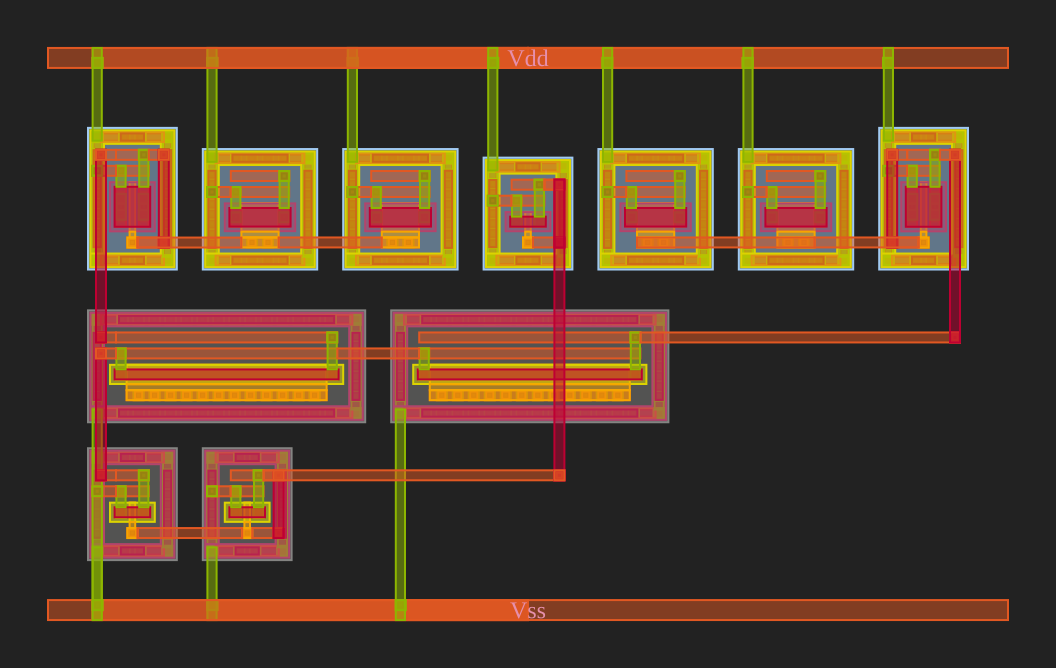

In [7]:
display_component(encoder_comp, scale=2, path=".")

In [8]:
component = encoder_comp.flatten()

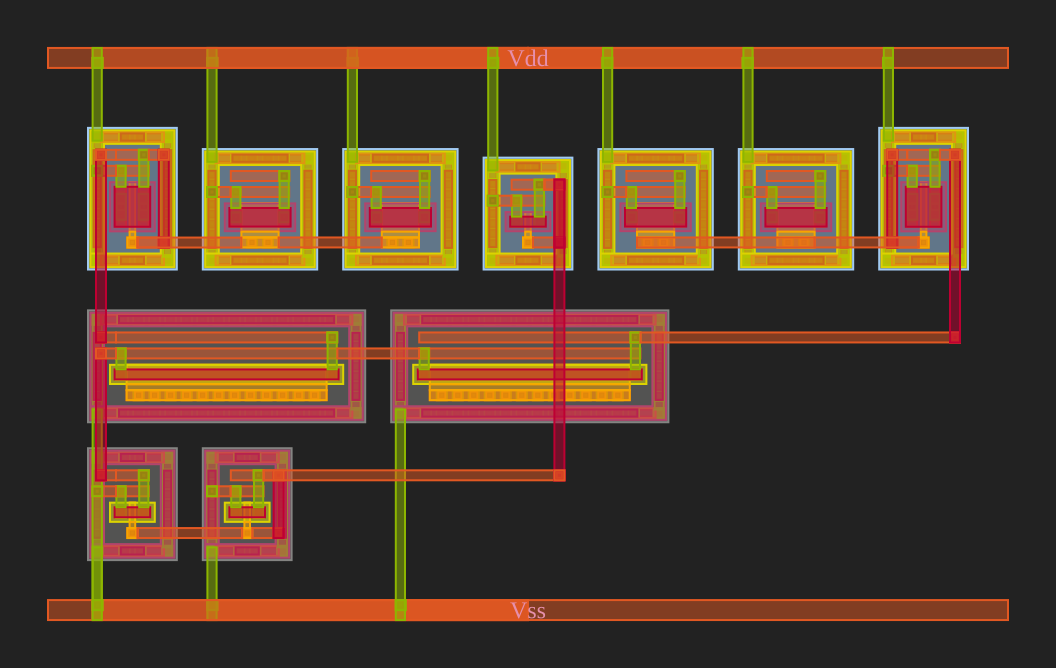

In [10]:
display_component(encoder_comp, scale=2, path=".")

In [7]:
# =========================================================================
# 5. ADD PHYSICAL PINS AND LABELS FOR LVS
# =========================================================================
psize=(0.5,0.5)
move_info = list()
# Mapeo de nombres de pines a sus puertos correspondientes en encoder_comp
pins_to_create = {
    
    # Entradas Diferenciales (NMOS)
    "Vin": xm1_ref.ports["multiplier_0_gate_W"],
    "Vin_neg": xm2_ref.ports["multiplier_0_gate_E"],
    
    # Entradas de Corriente (Drenadores de PMOS auxiliares)
    "lex_1_i": xm8_ref.ports["multiplier_0_drain_S"],
    "ex_2_i": xm5_ref.ports["multiplier_0_drain_S"],
    "Iex_3_i": xm7_ref.ports["multiplier_0_drain_S"],
    "Iex_4_i": xm6_ref.ports["multiplier_0_drain_S"],
}

#Vin
vin_label = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
vin_label.add_label(text="Vin",layer=pdk.get_glayer("met1_pin"))
move_info.append((vin_label, xm1_ref.ports["multiplier_0_gate_W"],None))

#Vin_neg
vinneg_label = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
vinneg_label.add_label(text="Vin_neg",layer=pdk.get_glayer("met1_pin"))
move_info.append((vinneg_label, xm2_ref.ports["multiplier_0_gate_E"], None))

#Iex_1_i
Iex_1_i_label = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
Iex_1_i_label.add_label(text="Iex_1_i",layer=pdk.get_glayer("met1_pin"))
move_info.append((Iex_1_i_label, xm8_ref.ports["multiplier_0_drain_N"], None))

#Iex_2_i
Iex_2_i_label = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
Iex_2_i_label.add_label(text="ex_2_i",layer=pdk.get_glayer("met1_pin"))
move_info.append((Iex_2_i_label, xm5_ref.ports["multiplier_0_drain_N"], None))

#Iex_3_i
Iex_3_i_label = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
Iex_3_i_label.add_label(text="lex_3_i",layer=pdk.get_glayer("met1_pin"))
move_info.append((Iex_3_i_label, xm7_ref.ports["multiplier_0_drain_N"], None))

#Iex_4_i
Iex_4_i_label = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
Iex_4_i_label.add_label(text="Iex_4_i",layer=pdk.get_glayer("met1_pin"))
move_info.append((Iex_4_i_label, xm6_ref.ports["multiplier_0_drain_N"], None))


for comp, prt, alignment in move_info:
        alignment = ('c','b') if alignment is None else alignment
        compref = align_comp_to_port(comp, prt, alignment=alignment)
        encoder_comp.add(compref)
        
#encoder_comp.flatten()


for pin_name, port in pins_to_create.items():
    # Extract center position, size, and orientation from port object
    center = port.center
    width = port.width
    height = port.width  # Standard square pin area around the port center

    # # 1. Add pin rectangle shape on met2_pin
    # encoder_comp.add_polygon(
    #     [
    #         (center[0] - width / 2, center[1] - height / 2),
    #         (center[0] + width / 2, center[1] - height / 2),
    #         (center[0] + width / 2, center[1] + height / 2),
    #         (center[0] - width / 2, center[1] + height / 2),
    #     ],
    #     layer=pdk.get_glayer("met2_label") ,
    # )

    encoder_comp.add_port(pin_name, center=center, width=0.5, orientation=180, layer=pdk.get_glayer("met1"),  port_type="electrical") 

    # 2. Add text label on met2_pin layer for net identity
#     encoder_comp.add_label(text=pin_name, position=center, layer=pdk.get_glayer("met2_label"), magnification=1)
    

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 17 in 'encoder'
  gdspath = component.write_gds(
2026-08-14 01:10:58.557 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.2", "type": "reload", "file": "/tmp/gdsfactory/encoder.gds"}
/tmp/ipykernel_995/4079901310.py:2: UserWarning: Unnamed cells, 17 in 'encoder'
  encoder_comp.write_gds()
2026-08-14 01:10:58.565 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/gdsfactory/encoder.gds'


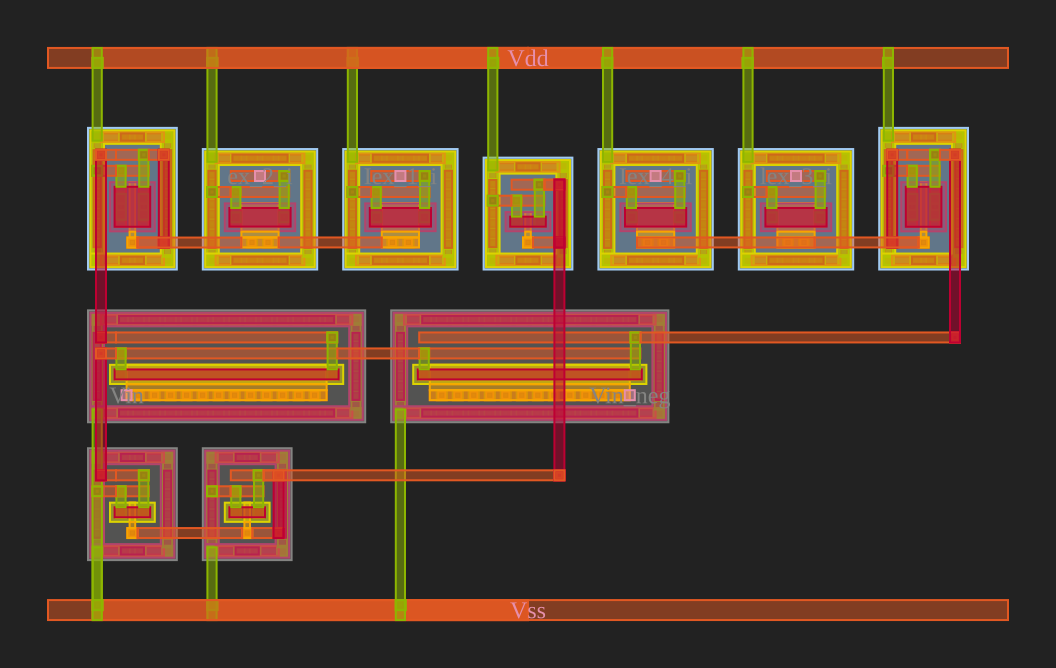

In [8]:
encoder_comp.show()
encoder_comp.write_gds()
display_component(encoder_comp, scale=2, path=".")

In [9]:
evaluate_bbox(encoder_comp)

(48.0, 28.635)

In [10]:
encoder_comp.pprint_ports()

┏━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ name    ┃ width ┃ center          ┃ orientation ┃ layer   ┃ port_type  ┃
┡━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ Vdd     │ 1.0   │ [22.0, 27.935]  │ 180         │ [36, 0] │ electrical │
│ Vss     │ 1.0   │ [22.0, 0.3]     │ 180         │ [36, 0] │ electrical │
│ Vin     │ 0.5   │ [1.93, 11.055]  │ 180         │ [34, 0] │ electrical │
│ Vin_neg │ 0.5   │ [27.09, 11.055] │ 180         │ [34, 0] │ electrical │
│ lex_1_i │ 0.5   │ [15.62, 21.775] │ 180         │ [34, 0] │ electrical │
│ ex_2_i  │ 0.5   │ [8.6, 21.775]   │ 180         │ [34, 0] │ electrical │
│ Iex_3_i │ 0.5   │ [35.4, 21.775]  │ 180         │ [34, 0] │ electrical │
│ Iex_4_i │ 0.5   │ [28.38, 21.775] │ 180         │ [34, 0] │ electrical │
└─────────┴───────┴─────────────────┴─────────────┴─────────┴────────────┘

In [12]:
#encoder_comp.name="encoder"
drc_result = gf180.drc_magic(encoder_comp, encoder_comp.name)

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/glayout/pdk/mappedpdk.py:495: UserWarning: Unnamed cells, 23 in 'encoder'
  layout.write_gds(gds_path)
2026-08-14 01:07:20.095 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmprwk86_gm/encoder.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 528 - Compiled on Wed Jun 18 09:45:25 PM CEST 2025.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmprwk86_gm/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "encoder".
Reading "Unnamed_5bac2e3e".
Reading "Unnamed_6620d976".
Re

In [15]:
# spice
# .subckt encoder Vdd Vss Vin Vin_neg Iex_1_i Iex_2_i Iex_3_i Iex_4_i
# *.PININFO Vdd:B Vss:B Vin:I Vin_neg:I Iex_1_i:O Iex_4_i:O Iex_2_i:O Iex_3_i:O
# XM1 x Vin a Vss nfet_03v3 L=10u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
# XM2 y Vin_neg a Vss nfet_03v3 L=10u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
# XM3 x x Vdd Vdd pfet_03v3 L=0.28u W=2u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
# XM4 y y Vdd Vdd pfet_03v3 L=0.28u W=2u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
# XM5 Iex_2_i x Vdd Vdd pfet_03v3 L=1.86u W=0.93u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
# XM7 Iex_3_i y Vdd Vdd pfet_03v3 L=1.86u W=0.93u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
# XM9 a net1 Vss Vss nfet_03v3 L=0.28u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
# XM10 net1 net1 Vss Vss nfet_03v3 L=0.28u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
# XM11 net1 net1 Vdd Vdd pfet_03v3 L=0.28u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
# XM6 Iex_4_i y Vdd Vdd pfet_03v3 L=1.86u W=0.93u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
# XM8 Iex_1_i x Vdd Vdd pfet_03v3 L=1.86u W=0.93u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
# .ends


In [11]:
#At first, we need to properly set PDKPATH and PDK_ROOT 

print("Making sure your environment varriables are still correctly set")
print(" I am using PDK in: ",os.environ['PDK_ROOT'],"\n PDK name: ",os.environ['PDK'],"\n The PDK files are at: ",os.environ['PDKPATH'])

Making sure your environment varriables are still correctly set
 I am using PDK in:  /foss/pdks 
 PDK name:  gf180mcuD 
 The PDK files are at:  /foss/pdks/gf180mcuD


In [12]:
magicrc_file = Path(os.environ['PDKPATH']) / "libs.tech" / "magic" / f"{os.environ['PDK']}.magicrc"
design_name=encoder_comp.name
path_to_dir = "/foss/designs/CapiMagics/layout/encoder/"

pex_path = path_to_dir + f"{design_name}.spice"
gds_path = path_to_dir + f"{design_name}.gds"

encoder_comp.write_gds(str(gds_path))
    
magic_script_content = f"""
drc off            
gds flatglob *\\$\\$*
gds read {gds_path}

flatten {design_name}
load {design_name}
select top cell
extract do local
extract all
ext2sim labels on
ext2sim
extresist tolerance 10
extresist
ext2spice lvs
ext2spice cthresh 0
ext2spice extresist on
ext2spice -o {str(pex_path)}
exit
"""

with tempfile.NamedTemporaryFile(mode='w', delete=False) as magic_script_file:
    magic_script_file.write(magic_script_content)
    magic_script_path = magic_script_file.name
    
magic_cmd = f"bash -c 'magic -rcfile {magicrc_file} -noconsole -dnull < {magic_script_path}'",
magic_subproc = subprocess.run(
    magic_cmd, 
    shell=True,
    check=True,
    capture_output=True
)
magic_subproc_code = magic_subproc.returncode
magic_subproc_out = magic_subproc.stdout.decode('utf-8')
print(magic_subproc_out)

/tmp/ipykernel_250/4155124458.py:8: UserWarning: Unnamed cells, 11 in 'encoder'
  encoder_comp.write_gds(str(gds_path))
2026-08-13 20:14:14.667 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/CapiMagics/layout/encoder/encoder.gds'


KeyboardInterrupt: 

In [11]:
path_to_dir = "/foss/designs/CapiMagics/layout/encoder/"

In [12]:
import glob
extensions = [
            "els"
            "*.gds",
            "*.ext",
            "*.res.ext",
            "*.lvs.rpt",
            "*_lvs.rpt",
            "*.nodes",
            "*.sim",
            "*.pex.spice",
            "*_pex.spice"
            ]
files_to_delete = []
for ext in extensions:
    files_to_delete.extend(glob.glob(ext))
    
# Delete the files
for file_path in files_to_delete:
    try:
        os.remove(file_path)
        print(f"Deleted: {file_path}")
    except OSError as e:
        print(f"Error deleting {file_path}: {e}")

Deleted: compass_4255401a$1.ext
Deleted: compass_4255401a.ext
Deleted: compass_df8d0505$1.ext
Deleted: compass_df8d0505$10.ext
Deleted: compass_df8d0505$11.ext
Deleted: compass_df8d0505$2.ext
Deleted: compass_df8d0505$3.ext
Deleted: compass_df8d0505$4.ext
Deleted: compass_df8d0505$5.ext
Deleted: compass_df8d0505$6.ext
Deleted: compass_df8d0505$7.ext
Deleted: compass_df8d0505$8.ext
Deleted: compass_df8d0505$9.ext
Deleted: compass_df8d0505.ext
Deleted: c_route_16d85055.ext
Deleted: c_route_23cc703f.ext
Deleted: c_route_403e1874.ext
Deleted: c_route_5302c22c.ext
Deleted: c_route_554fe7e4.ext
Deleted: c_route_8021189c.ext
Deleted: c_route_93a388b3.ext
Deleted: c_route_dc8e06bf.ext
Deleted: L_route_2db34a5f.ext
Deleted: L_route_468abff0.ext
Deleted: L_route_99bcc725.ext
Deleted: L_route_a7e4c6c4.ext
Deleted: L_route_bbaf4194.ext
Deleted: L_route_c6a844ea.ext
Deleted: L_route_c7297e08.ext
Deleted: L_route_d10aafcd.ext
Deleted: L_route_dfe87d05.ext
Deleted: L_route_e367eb1d.ext
Deleted: L_rou

In [13]:
gf180.lvs_netgen(
    layout=encoder_comp,
    design_name = encoder_comp.name,
    pdk_root = Path(os.environ['PDKPATH']),
    lvs_setup_tcl_file = Path(os.environ['PDKPATH']) / "libs.tech" / "netgen" / f"{os.environ['PDK']}_setup.tcl",
    netlist = Path(str(path_to_dir + "encoder_lvs.spice")),
    output_file_path =  Path(str(path_to_dir))
)

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/glayout/pdk/mappedpdk.py:717: UserWarning: Unnamed cells, 17 in 'encoder'
  layout.write_gds(str(gds_path))
2026-08-14 01:11:15.252 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpetn_7l0c/encoder.gds'


using user specified pdk_root, will search for required files in the specified directory

Magic 8.3 revision 528 - Compiled on Wed Jun 18 09:45:25 PM CEST 2025.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.525-0-gf2e289d
Library written using GDS-II Release 6.0
Library name: library
Reading "encoder".
Reading "Unnamed_7de0eb72".
Reading "Un

{'magic_subproc_code': 0,
 'netgen_subproc_code': 0,
 'result_str': 'LVS run succeeded\nErrors found in LVS report: /tmp/tmpetn_7l0c/encoder_lvs.rpt'}

In [14]:
gf180.layers

{'metal5': (81, 0),
 'via4': (41, 0),
 'metal4': (46, 0),
 'via3': (40, 0),
 'metal3': (42, 0),
 'via2': (38, 0),
 'metal2': (36, 0),
 'via1': (35, 0),
 'metal1': (34, 0),
 'contact': (33, 0),
 'poly2': (30, 0),
 'comp': (22, 0),
 'nplus': (32, 0),
 'pplus': (31, 0),
 'nwell': (21, 0),
 'lvpwell': (204, 0),
 'dnwell': (12, 0),
 'CAP_MK': (117, 5),
 'metal5_label': (81, 10),
 'metal4_label': (46, 10),
 'metal3_label': (42, 10),
 'metal2_label': (36, 10),
 'metal1_label': (34, 10),
 'poly2_label': (30, 10),
 'comp_label': (22, 10)}

In [15]:
gf180.glayers

{'met5': 'metal5',
 'via4': 'via4',
 'met4': 'metal4',
 'via3': 'via3',
 'met3': 'metal3',
 'via2': 'via2',
 'met2': 'metal2',
 'via1': 'via1',
 'met1': 'metal1',
 'mcon': 'contact',
 'poly': 'poly2',
 'active_diff': 'comp',
 'active_tap': 'comp',
 'n+s/d': 'nplus',
 'p+s/d': 'pplus',
 'nwell': 'nwell',
 'pwell': 'lvpwell',
 'dnwell': 'dnwell',
 'capmet': 'CAP_MK',
 'met5_pin': 'metal5_label',
 'met4_pin': 'metal4_label',
 'met3_pin': 'metal3_label',
 'met2_pin': 'metal2_label',
 'met1_pin': 'metal1_label',
 'poly_pin': 'poly2_label',
 'active_diff_pin': 'comp_label',
 'met5_label': 'metal5_label',
 'met4_label': 'metal4_label',
 'met3_label': 'metal3_label',
 'met2_label': 'metal2_label',
 'met1_label': 'metal1_label',
 'poly_label': 'poly2_label',
 'active_diff_label': 'comp_label'}